In [10]:
from pathlib import Path

import pandas as pd

# --- config ---
INPUT_PATH = Path("csvs/adnimerged.csv")
OUTPUT_PATH = Path("csvs/adnimerged_longitudinal.csv")

BASELINE_VISITS = {"sc", "bl"}
FOLLOWUP_VISITS = ["m12", "m24"]#, "m36", "m48"]
CANONICAL_VISITS = BASELINE_VISITS | set(FOLLOWUP_VISITS)
MIN_IMAGES_PER_SET = 3
TARGET_GROUPS = ["CN", "sMCI", "pMCI", "AD"]


def visit_slot(visit: str) -> str:
    return "baseline" if visit in BASELINE_VISITS else visit


def assign_group(patient_df: pd.DataFrame):
    """GROUP definido só pelas visitas canônicas (sc/bl + m12 + m24)."""
    g = patient_df[patient_df["VISIT"].isin(CANONICAL_VISITS)].sort_values(
        ["MRI_DATE", "ID_IMG"]
    )
    if g.empty:
        return pd.NA

    diags = set(g["DIAG"])

    if diags == {"CN"}:
        return "CN"
    if diags == {"AD"}:
        return "AD"
    if diags == {"MCI"}:
        return "sMCI"
    if "MCI" in diags and "AD" in diags:
        return "pMCI"
    return pd.NA


def patient_has_all_required_visits(visit_set: set[str]) -> bool:
    return bool(visit_set & BASELINE_VISITS) and set(FOLLOWUP_VISITS).issubset(visit_set)


def one_image_per_slot(df: pd.DataFrame) -> pd.DataFrame:
    out = df[df["VISIT"].isin(CANONICAL_VISITS)].copy()
    out["slot"] = out["VISIT"].map(visit_slot)
    out = out.sort_values(["ID_PT", "slot", "MRI_DATE", "ID_IMG"])
    return out.drop_duplicates(["ID_PT", "slot"], keep="first")


def build_longitudinal_sets(
    df: pd.DataFrame,
    *,
    require_all_visits: bool,
    min_images: int = MIN_IMAGES_PER_SET,
) -> tuple[pd.DataFrame, pd.Series]:
    per_slot = one_image_per_slot(df)
    slots_per_pt = per_slot.groupby("ID_PT").size()
    visits_per_pt = df.groupby("ID_PT")["VISIT"].apply(set)

    eligible = slots_per_pt.index
    if require_all_visits:
        eligible = visits_per_pt[visits_per_pt.apply(patient_has_all_required_visits)].index
    else:
        has_baseline = per_slot.loc[per_slot["slot"] == "baseline", "ID_PT"].unique()
        eligible = pd.Index(has_baseline)

    eligible = eligible[slots_per_pt.reindex(eligible).fillna(0) >= min_images]
    longitudinal = per_slot[per_slot["ID_PT"].isin(eligible)].copy()
    longitudinal = longitudinal.sort_values(["ID_PT", "MRI_DATE", "ID_IMG"])
    return longitudinal, slots_per_pt.reindex(eligible)


# --- 1) leitura e remoção de repeats ---
raw = pd.read_csv(INPUT_PATH)
raw["MRI_DATE"] = pd.to_datetime(raw["MRI_DATE"], errors="coerce")

is_repeat = raw["DESCRIPTION"].str.contains("repeat", case=False, na=False)
df = raw.loc[~is_repeat].copy()

print(f"Linhas originais: {len(raw)} | removidas (repeat): {is_repeat.sum()} | restantes: {len(df)}")

# --- 2) GROUP por paciente (apenas visitas canônicas, sem repeat) ---
group_by_pt = df.groupby("ID_PT").apply(assign_group, include_groups=False)

print("\nPacientes por GROUP (visitas canônicas sc/bl + m12 + m24):")
print(group_by_pt.value_counts(dropna=False).sort_index())

# --- 3) coorte estrita: paciente com sc/bl + m12 + m24 + m36 + m48 ---
visits_by_pt = df.groupby("ID_PT")["VISIT"].apply(set)
strict_pts = visits_by_pt[visits_by_pt.apply(patient_has_all_required_visits)].index

longitudinal, _ = build_longitudinal_sets(
    df, require_all_visits=False, min_images=MIN_IMAGES_PER_SET
)
longitudinal["GROUP"] = longitudinal["ID_PT"].map(group_by_pt)
longitudinal = longitudinal[longitudinal["GROUP"].isin(TARGET_GROUPS)].copy()

df_flex = df[df["ID_PT"].isin(longitudinal["ID_PT"].unique())].copy()

# --- 5) salvar ---

longitudinal.to_csv(OUTPUT_PATH, index=False)
print(f"Salvo flexível: {OUTPUT_PATH} ({len(longitudinal)} linhas)")

display(longitudinal.groupby(["GROUP", "slot"]).size().unstack(fill_value=0))

Linhas originais: 12921 | removidas (repeat): 3757 | restantes: 9164

Pacientes por GROUP (visitas canônicas sc/bl + m12 + m24):
AD      165
CN      184
pMCI     99
sMCI    230
<NA>    625
Name: count, dtype: int64
Salvo flexível: csvs/adnimerged_longitudinal.csv (1221 linhas)


slot,baseline,m12,m24
GROUP,,,
AD,83,83,83
CN,136,136,136
pMCI,81,81,81
sMCI,107,107,107


In [14]:
ROW_ORDER = ["CN", "sMCI", "pMCI", "AD", "All"]
COL_ORDER = ["F", "M", "All"]

pacientes = longitudinal.drop_duplicates("ID_PT")

tabela_pacientes = (
    pd.crosstab(pacientes["GROUP"], pacientes["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

tabela_imagens = (
    pd.crosstab(longitudinal["GROUP"], longitudinal["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

# mantém tabela agregada (sem SEX) para o gráfico da célula seguinte
img_por_timepoint = (
    longitudinal.groupby(["GROUP", "slot"])["ID_IMG"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["baseline", "m12", "m24"])
)

print("Pacientes (ID_PT) por GROUP × SEX:")
display(tabela_pacientes)

print("\nImagens (ID_IMG) por GROUP × SEX:")
display(tabela_imagens)

Pacientes (ID_PT) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,72,64,136
sMCI,38,69,107
pMCI,33,48,81
AD,41,42,83
All,184,223,407



Imagens (ID_IMG) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,216,192,408
sMCI,114,207,321
pMCI,99,144,243
AD,123,126,249
All,552,669,1221


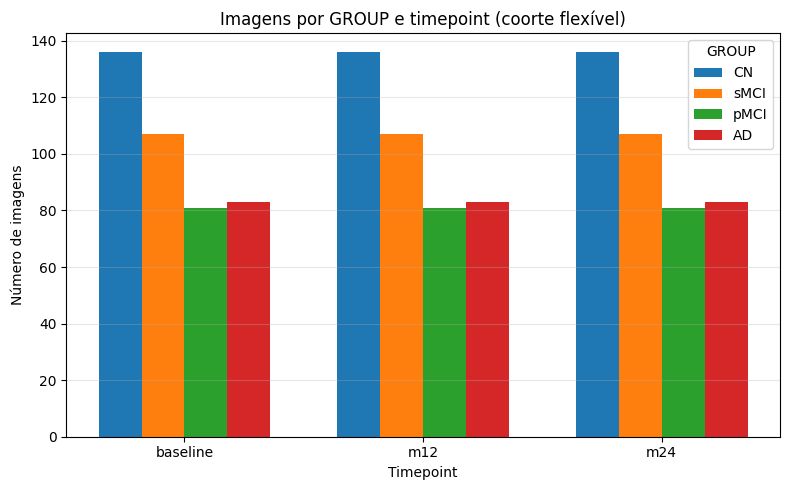

In [12]:
import matplotlib.pyplot as plt

plot_df = img_por_timepoint.reindex(TARGET_GROUPS)
x = plot_df.columns.tolist()
width = 0.18
groups = plot_df.index.tolist()
offsets = [(i - (len(groups) - 1) / 2) * width for i in range(len(groups))]

fig, ax = plt.subplots(figsize=(8, 5))
for offset, group in zip(offsets, groups):
    ax.bar(
        [i + offset for i in range(len(x))],
        plot_df.loc[group].values,
        width=width,
        label=group,
    )

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_xlabel("Timepoint")
ax.set_ylabel("Número de imagens")
ax.set_title("Imagens por GROUP e timepoint (coorte flexível)")
ax.legend(title="GROUP")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
CLINICAL_VARS = {
    "AGE": "Age (years)",
    "MMSE_SCORE": "MMSE",
    "ADAS_SCORE": "ADAS",
  # "CDR_GLOBAL": "CDR",
    "FAQ_SCORE": "FAQ",
}

SLOT_ORDER = ["baseline", "m12", "m24"]
SLOT_SUFFIX = {"baseline": "_bl", "m12": "_12m", "m24": "_24m"}


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


def gender_m_f(series: pd.Series) -> str:
    return f"{(series == 'M').sum()}/{(series == 'F').sum()}"


row_labels = [
    f"{group}{SLOT_SUFFIX[slot]}"
    for group in TARGET_GROUPS
    for slot in SLOT_ORDER
]

col_order = [
    "Sample size",
    "Gender (male/female)",
    *CLINICAL_VARS.values(),
]

table_data = {}

for group in TARGET_GROUPS:
    for slot in SLOT_ORDER:
        row = f"{group}{SLOT_SUFFIX[slot]}"
        sub = longitudinal[
            (longitudinal["GROUP"] == group) & (longitudinal["slot"] == slot)
        ]

        table_data[row] = {
            "Sample size": len(sub),
            "Gender (male/female)": gender_m_f(sub["SEX"]),
        }
        for var, label in CLINICAL_VARS.items():
            table_data[row][label] = mean_std(sub[var])

tabela_caracteristicas = (
    pd.DataFrame(table_data)
    .T
    .reindex(index=row_labels)
    .reindex(columns=col_order)
)

print("Características por GROUP e timepoint (mean ± SD):")
display(tabela_caracteristicas)

print("\nNota: dados representados como média ± DP (SD).")



Características por GROUP e timepoint (mean ± SD):


,Sample size,Gender (male/female),Age (years),MMSE,ADAS,FAQ
CN_bl,136,64/72,76.18 ± 5.26,29.23 ± 0.97,5.64 ± 2.65,0.12 ± 0.46
CN_12m,136,64/72,77.29 ± 5.28,29.26 ± 1.10,5.39 ± 2.68,0.17 ± 0.93
CN_24m,136,64/72,78.26 ± 5.33,29.19 ± 1.02,5.37 ± 2.77,0.22 ± 0.83
sMCI_bl,107,69/38,75.04 ± 6.73,27.38 ± 1.76,10.13 ± 4.10,2.63 ± 3.75
sMCI_12m,107,69/38,76.09 ± 6.74,27.50 ± 2.08,10.13 ± 4.70,3.65 ± 4.42
sMCI_24m,107,69/38,77.11 ± 6.76,26.98 ± 2.67,11.58 ± 5.00,4.25 ± 4.89
pMCI_bl,81,48/33,74.63 ± 7.12,26.44 ± 1.64,13.17 ± 4.22,5.72 ± 4.81
pMCI_12m,81,48/33,75.67 ± 7.09,24.53 ± 2.85,15.46 ± 5.40,9.09 ± 5.52
pMCI_24m,81,48/33,76.70 ± 7.09,22.31 ± 3.88,18.72 ± 7.13,14.30 ± 6.13
AD_bl,83,42/41,75.93 ± 7.13,23.19 ± 1.92,18.78 ± 6.13,13.14 ± 6.78



Nota: dados representados como média ± DP (SD).
